In [74]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

class TradingGymEnv(gym.Env):
    def __init__(
        self,
        df,
        state_features,
        transaction_cost=0.001,
        lambda_vol=0.01,
        lambda_dd=0.02,
        reward_clip=None
    ):
        super().__init__()

        self.df = df.reset_index(drop=True).copy()
        self.state_features = state_features
        self.transaction_cost = transaction_cost
        self.lambda_vol = lambda_vol
        self.lambda_dd = lambda_dd
        self.reward_clip = reward_clip
        self.n_steps = len(self.df)

        required_cols = ["raw_return_1d", "regime_volatility"]
        missing_cols = [c for c in required_cols if c not in self.df.columns]
        if missing_cols:
            raise ValueError(f"DataFrame is missing required columns: {missing_cols}")

        # 5 discrete target positions (short to long)
        # 0 -> -1.0, 1 -> -0.5, 2 -> 0.0, 3 -> 0.5, 4 -> 1.0
        self.action_space = spaces.Discrete(5)
        self.position_levels = np.array([-1.0, -0.5, 0.0, 0.5, 1.0], dtype=np.float32)

        # Observation = state_features + current position
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.state_features) + 1,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0.0
        self.total_reward = 0.0
        self.portfolio_value = 1.0
        self.running_max = 1.0

        state = self._get_state()
        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step
        }
        return state, info

    def _get_state(self):
        market_state = self.df.loc[self.current_step, self.state_features].values.astype(np.float32)
        full_state = np.append(market_state, np.float32(self.position))
        return full_state.astype(np.float32)

    def step(self, action):
        reward = 0.0

        # Stop before next-day return becomes unavailable
        if self.current_step >= self.n_steps - 2:
            terminated = True
            truncated = False
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)
            info = {
                "portfolio_value": self.portfolio_value,
                "position": self.position,
                "step": self.current_step
            }
            return next_state, reward, terminated, truncated, info

        action = int(action)
        target_position = float(self.position_levels[action])

        # Transaction cost depends on how much position changes
        position_change = abs(target_position - self.position)
        trade_cost = position_change * self.transaction_cost

        # Apply new position
        self.position = target_position

        # Next-day raw return drives PnL
        next_return = float(self.df.loc[self.current_step + 1, "raw_return_1d"])
        pnl = self.position * next_return

        # Risk penalties
        current_vol = float(self.df.loc[self.current_step, "regime_volatility"])
        current_drawdown = max(
            0.0,
            (self.running_max - self.portfolio_value) / (self.running_max + 1e-8)
        )

        reward = pnl - trade_cost - self.lambda_vol * current_vol - self.lambda_dd * current_drawdown

        if self.reward_clip is not None:
            reward = float(np.clip(reward, -self.reward_clip, self.reward_clip))
        else:
            reward = float(reward)

        # Update portfolio
        self.total_reward += reward
        self.portfolio_value *= (1 + reward)
        self.running_max = max(self.running_max, self.portfolio_value)

        # Move forward
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 2
        truncated = False

        if not terminated:
            next_state = self._get_state()
        else:
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)

        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step,
            "trade_cost": trade_cost,
            "pnl": pnl,
            "drawdown": current_drawdown
        }

        return next_state, reward, terminated, truncated, info

In [75]:
import pandas as pd
import numpy as np

# ================================
# Load dataset
# ================================
df_all = pd.read_csv("global_trading_dataset.csv")

# Convert date
df_all["date"] = pd.to_datetime(df_all["date"])

# Sort by market and time
df_all = df_all.sort_values(["market", "date"]).reset_index(drop=True)

# Ensure numeric columns are float
numeric_cols = ["open", "high", "low", "close", "volume"]
df_all[numeric_cols] = df_all[numeric_cols].astype(float)

# ================================
# Create core return features
# ================================
df_all["raw_return_1d"] = df_all.groupby("market")["close"].pct_change()

df_all["return_5d"] = (
    df_all.groupby("market")["close"].pct_change(5)
)

df_all["return_10d"] = (
    df_all.groupby("market")["close"].pct_change(10)
)

# ================================
# Moving averages
# ================================
df_all["MA_5"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(5).mean())
)

df_all["MA_20"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(20).mean())
)

df_all["MA_gap"] = (df_all["MA_5"] / df_all["MA_20"]) - 1

# Trend strength feature (important for PPO)
df_all["trend_strength"] = df_all["MA_gap"]

# Bull / Bear regime indicator
df_all["bull_flag"] = (df_all["MA_5"] > df_all["MA_20"]).astype(int)

# ================================
# Volatility features
# ================================
df_all["volatility_10"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(10).std())
)

# Regime volatility (used in reward)
df_all["regime_volatility"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(20).std())
)

# ================================
# Volume change
# ================================
df_all["volume_change"] = (
    df_all.groupby("market")["volume"].pct_change()
)

# ================================
# RSI (14)
# ================================
def compute_rsi(series, window=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))

    return rsi

df_all["RSI_14"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: compute_rsi(x, 14))
)

# ================================
# MACD
# ================================
ema12 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=12).mean())
ema26 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=26).mean())

df_all["MACD"] = ema12 - ema26

# ================================
# Position feature placeholder
# (used by RL environment)
# ================================
df_all["position_feature"] = 0.0

# ================================
# Clean NaN / Inf values
# ================================
df_all = df_all.replace([np.inf, -np.inf], np.nan)

df_all = df_all.dropna().reset_index(drop=True)

# ================================
# Dataset diagnostics
# ================================
print("Dataset shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())

print("\nHead:")
print(df_all.head())

print("\nMarket distribution:")
print(df_all["market"].value_counts())

print("\nNaN count:")
print(df_all.isna().sum())

print("\nInf count:")
print(np.isinf(df_all.select_dtypes(include=[float, int])).sum())

Dataset shape: (7258, 22)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'market', 'return_1d', 'return_5d', 'return_10d', 'MA_5', 'MA_20', 'MA_gap', 'volatility_10', 'volume_change', 'RSI_14', 'MACD', 'raw_return_1d', 'trend_strength', 'bull_flag', 'regime_volatility', 'position_feature']

Head:
        date        close         high          low         open    volume  \
0 2020-03-05  3071.677002  3074.257080  3022.926025  3036.155029  445400.0   
1 2020-03-06  3034.510986  3052.444092  3029.462891  3039.939941  362100.0   
2 2020-03-09  2943.291016  2989.205078  2940.714111  2987.180908  414600.0   
3 2020-03-10  2996.761963  3000.295898  2904.799072  2918.935059  393300.0   
4 2020-03-11  2968.517090  3010.029053  2968.517090  3001.761963  352500.0   

  market  return_1d  return_5d  return_10d  ...    MA_gap  volatility_10  \
0     CN   0.019926   0.026860    0.013703  ...  0.005506       0.018136   
1     CN  -0.012100   0.053538   -0.001697  ...  0.013188       0.01

In [76]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ======================================
# State features
# ======================================
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

state_features = base_features + regime_features
# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# it must never be scaled
scale_cols = base_features + regime_features

# ======================================
# Utility: time split
# ======================================
def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test

# ======================================
# Prepare RL dataframe
# ======================================
df_rl = df_all.copy()

df_rl = df_rl.replace([np.inf, -np.inf], np.nan)
df_rl = df_rl.dropna(subset=state_features).reset_index(drop=True)

# ======================================
# Use US market first for initial PPO testing
# ======================================
df_us = (
    df_rl[df_rl["market"] == "US"]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

# Split before scaling to avoid leakage
df_us_train, df_us_val, df_us_test = time_split(df_us, train_ratio=0.6, val_ratio=0.2)

print("US split sizes:")
print("Train:", df_us_train.shape)
print("Val  :", df_us_val.shape)
print("Test :", df_us_test.shape)

# ======================================
# Fit scaler on TRAIN only
# ======================================
scaler = StandardScaler()
df_us_train[scale_cols] = scaler.fit_transform(df_us_train[scale_cols])
df_us_val[scale_cols] = scaler.transform(df_us_val[scale_cols])
df_us_test[scale_cols] = scaler.transform(df_us_test[scale_cols])

# ======================================
# Data quality checks
# ======================================
for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n===== {name} =====")
    print("NaN count:")
    print(df_part[state_features].isna().sum())

    print("\nInf count:")
    print(np.isinf(df_part[scale_cols].select_dtypes(include=[float, int]).values).sum())

    print("\nScaled feature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])

# ======================================
# Environment sanity check (train only)
# ======================================
env = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

obs, info = env.reset()

print("\nInitial state:", obs)
print("Reset info:", info)
print("Observation shape:", obs.shape)
print("Any NaN in obs:", np.isnan(obs).any())
print("Any Inf in obs:", np.isinf(obs).any())

# Random rollout test using new 5-action space
done = False
while not done:
    action = np.random.choice([0, 1, 2, 3, 4])
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print("\nFinal portfolio value:", info["portfolio_value"])
print("Total reward:", env.total_reward)

US split sizes:
Train: (880, 22)
Val  : (293, 22)
Test : (294, 22)

===== TRAIN =====
NaN count:
return_1d            0
return_5d            0
return_10d           0
MA_gap               0
volatility_10        0
volume_change        0
RSI_14               0
MACD                 0
trend_strength       0
regime_volatility    0
bull_flag            0
dtype: int64

Inf count:
0

Scaled feature summary:
                           mean       std       min       max
return_1d         -4.037175e-18  1.000569 -7.984855  6.185860
return_5d          0.000000e+00  1.000569 -6.160840  5.808628
return_10d        -1.614870e-17  1.000569 -5.740148  4.488765
MA_gap             1.614870e-17  1.000569 -5.589957  3.110504
volatility_10     -7.266914e-17  1.000569 -1.006580  6.778218
volume_change     -1.009294e-17  1.000569 -5.412564  6.719046
RSI_14            -3.229740e-16  1.000569 -2.694469  2.295799
MACD               3.229740e-17  1.000569 -4.456724  1.678690
trend_strength     1.614870e-17  1.00056

In [77]:
import numpy as np

print("Checking RL dataset quality...")

for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n==================== {name} ====================")

    # NaN check
    print("\nNaN count per feature:")
    print(df_part[state_features].isna().sum())

    # Inf check
    print("\nInf count in scaled features:")
    print(np.isinf(df_part[scale_cols].values).sum())

    # Extreme value check
    print("\nMax absolute value per feature:")
    print(np.abs(df_part[scale_cols]).max())

    # Feature statistics
    print("\nFeature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])

    # Position feature check
    print("\nPosition feature unique values:")
    print(df_part["position_feature"].unique())

Checking RL dataset quality...

==================== TRAIN ====================

NaN count per feature:
return_1d            0
return_5d            0
return_10d           0
MA_gap               0
volatility_10        0
volume_change        0
RSI_14               0
MACD                 0
trend_strength       0
regime_volatility    0
bull_flag            0
dtype: int64

Inf count in scaled features:
0

Max absolute value per feature:
return_1d            7.984855
return_5d            6.160840
return_10d           5.740148
MA_gap               5.589957
volatility_10        6.778218
volume_change        6.719046
RSI_14               2.694469
MACD                 4.456724
trend_strength       5.589957
regime_volatility    5.619918
bull_flag            1.339272
dtype: float64

Feature summary:
                           mean       std       min       max
return_1d         -4.037175e-18  1.000569 -7.984855  6.185860
return_5d          0.000000e+00  1.000569 -6.160840  5.808628
return_10d     

In [78]:
# ======================================
# Environment reset sanity checks
# ======================================

def check_env(env, name):
    print(f"\n================ {name} ENV CHECK ================")

    obs, info = env.reset()

    print("Initial obs:", obs)
    print("Obs shape:", obs.shape)
    print("Obs dtype:", obs.dtype)

    print("Action space:", env.action_space)
    print("Action space size:", env.action_space.n)

    print("Any NaN in obs:", np.isnan(obs).any())
    print("Any Inf in obs:", np.isinf(obs).any())

    print("\nReset info:", info)

    # Assertions
    assert obs.shape == (len(state_features) + 1,), f"Unexpected observation shape: {obs.shape}"
    assert env.action_space.n == 5, f"Unexpected action space: {env.action_space}"
    assert not np.isnan(obs).any(), "Observation contains NaN"
    assert not np.isinf(obs).any(), "Observation contains Inf"

    print("\nEnvironment reset check passed.")


# Train environment
env_train = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Validation environment
env_val = TradingGymEnv(
    df=df_us_val,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Test environment
env_test = TradingGymEnv(
    df=df_us_test,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Run checks
check_env(env_train, "TRAIN")
check_env(env_val, "VAL")
check_env(env_test, "TEST")


================ TRAIN ENV CHECK ================
Initial obs: [-0.58327395 -3.9689612  -3.1017973  -2.3557148   0.4780189   1.0686506
 -2.5828328  -1.3164753  -2.3557148   0.33237815 -1.3392725   0.        ]
Obs shape: (12,)
Obs dtype: float32
Action space: Discrete(5)
Action space size: 5
Any NaN in obs: False
Any Inf in obs: False

Reset info: {'portfolio_value': 1.0, 'position': 0.0, 'step': 0}

Environment reset check passed.

================ VAL ENV CHECK ================
Initial obs: [ 0.92530864  0.7694009   0.22121732 -0.23696515 -0.3479422   0.6488762
 -0.09381164 -0.47015023 -0.23696515 -0.50350845 -1.3392725   0.        ]
Obs shape: (12,)
Obs dtype: float32
Action space: Discrete(5)
Action space size: 5
Any NaN in obs: False
Any Inf in obs: False

Reset info: {'portfolio_value': 1.0, 'position': 0.0, 'step': 0}

Environment reset check passed.

================ TEST ENV CHECK ================
Initial obs: [ 0.13894847 -0.25589132 -0.2528363   0.06277673 -0.83810985  0.220

In [79]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
import random
import torch

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ======================================
# Training environment (TRAIN only)
# ======================================
train_env = DummyVecEnv([
    lambda: Monitor(
        TradingGymEnv(
            df=df_us_train,
            state_features=state_features,
            transaction_cost=0.002,
            lambda_vol=0.002,
            lambda_dd=0.005,
            reward_clip=None
        )
    )
])

# ======================================
# PPO model
# ======================================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    tensorboard_log="./ppo_trading_tensorboard/"
)

print("Starting PPO training on US TRAIN set...")

model.learn(
    total_timesteps=100000,
    progress_bar=True
)

print("Training finished.")

# Save model
model.save("ppo_us_train_model")

Using cpu device
Starting PPO training on US TRAIN set...
Logging to ./ppo_trading_tensorboard/PPO_8


Output()

-----------------------------
| time/              |      |
|    fps             | 1856 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------


-------------------------------------------
| time/                   |               |
|    fps                  | 1615          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00012929388 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.61         |
|    explained_variance   | -4.29         |
|    learning_rate        | 0.0001        |
|    loss                 | 0.0254        |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00206      |
|    value_loss           | 0.151         |
-------------------------------------------


------------------------------------------
| time/                   |              |
|    fps                  | 1676         |
|    iterations           | 3            |
|    time_elapsed         | 0            |
|    total_timesteps      | 768          |
| train/                  |              |
|    approx_kl            | 5.826261e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.61        |
|    explained_variance   | -7.58        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.00411     |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.001       |
|    value_loss           | 0.0567       |
------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -1.96        |
| time/                   |              |
|    fps                  | 1785         |
|    iterations           | 388          |
|    time_elapsed         | 55           |
|    total_timesteps      | 99328        |
| train/                  |              |
|    approx_kl            | 0.0006222739 |
|    clip_fraction        | 0.00117      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.423       |
|    explained_variance   | 0.208        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0105      |
|    n_updates            | 3870         |
|    policy_gradient_loss | -0.00175     |
|    value_loss           | 0.00111      |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -1.96        |
| time/                   |              |
|    fps                  | 1784         |
|    iterations           | 389          |
|    time_elapsed         | 55           |
|    total_timesteps      | 99584        |
| train/                  |              |
|    approx_kl            | 0.0012296597 |
|    clip_fraction        | 0.00469      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.434       |
|    explained_variance   | 0.391        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.00823     |
|    n_updates            | 3880         |
|    policy_gradient_loss | -0.00377     |
|    value_loss           | 0.00108      |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -1.96        |
| time/                   |              |
|    fps                  | 1784         |
|    iterations           | 390          |
|    time_elapsed         | 55           |
|    total_timesteps      | 99840        |
| train/                  |              |
|    approx_kl            | 0.0026011826 |
|    clip_fraction        | 0.00937      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.424       |
|    explained_variance   | 0.00296      |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0134      |
|    n_updates            | 3890         |
|    policy_gradient_loss | -0.00507     |
|    value_loss           | 0.000753     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 878          |
|    ep_rew_mean          | -1.9         |
| time/                   |              |
|    fps                  | 1784         |
|    iterations           | 391          |
|    time_elapsed         | 56           |
|    total_timesteps      | 100096       |
| train/                  |              |
|    approx_kl            | 0.0038561923 |
|    clip_fraction        | 0.0215       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.402       |
|    explained_variance   | 0.0237       |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0156      |
|    n_updates            | 3900         |
|    policy_gradient_loss | -0.0077      |
|    value_loss           | 0.000676     |
------------------------------------------


Training finished.


Validation final value: 1.4403034465948321
Test final value: 1.1629708379005228


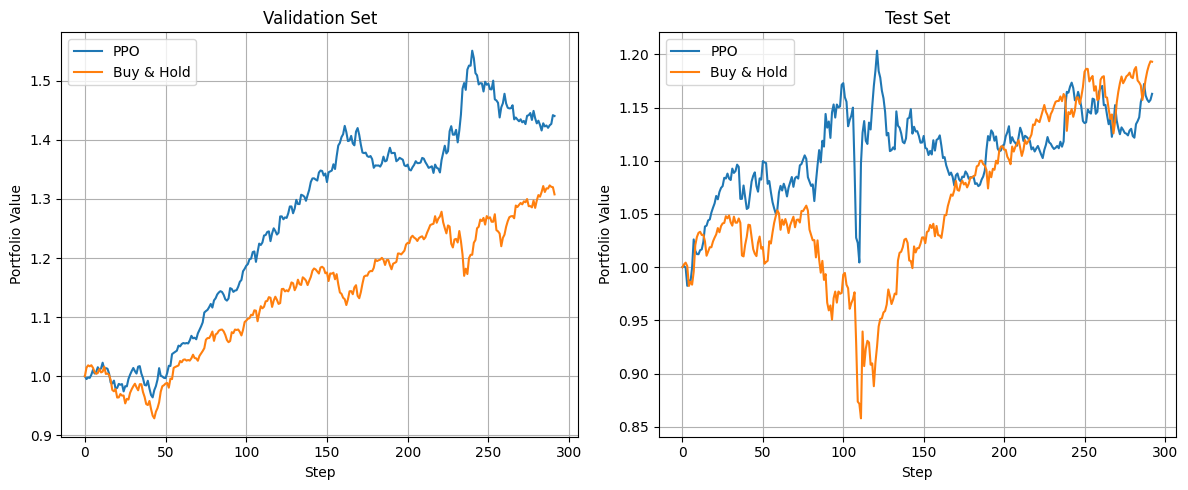

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# Backtest function for normal Gym env
# ======================================
def run_backtest(env, model):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]

    while not done:
        action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        portfolio_values.append(info["portfolio_value"])

    return np.array(portfolio_values)


# ======================================
# Run PPO backtest
# ======================================
val_equity = run_backtest(env_val, model)
test_equity = run_backtest(env_test, model)

print("Validation final value:", val_equity[-1])
print("Test final value:", test_equity[-1])


# ======================================
# Buy & Hold baseline
# ======================================
def buy_hold_curve(df):
    returns = df["raw_return_1d"].values
    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))
    return np.array(equity)


bh_val = buy_hold_curve(df_us_val)
bh_test = buy_hold_curve(df_us_test)


# ======================================
# Plot comparison
# ======================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_equity, label="PPO")
plt.plot(bh_val[:len(val_equity)], label="Buy & Hold")
plt.title("Validation Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_equity, label="PPO")
plt.plot(bh_test[:len(test_equity)], label="Buy & Hold")
plt.title("Test Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [81]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def performance_metrics(equity_curve):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns)

    sharpe = np.mean(returns) / (volatility + 1e-8)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_dd = np.max(drawdown)

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = performance_metrics(val_equity)
ppo_test_metrics = performance_metrics(test_equity)

bh_val_metrics = performance_metrics(bh_val[:len(val_equity)])
bh_test_metrics = performance_metrics(bh_test[:len(test_equity)])


# ======================================
# Create comparison table
# ======================================

results = pd.DataFrame({
    
    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,
    
    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics
    
})

print("\nPerformance Comparison")
print(results.round(4))


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
              PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return          0.4403              0.3077    0.1630        0.1931
Volatility            0.0077              0.0078    0.0113        0.0114
Sharpe Ratio          0.1659              0.1223    0.0515        0.0587
Max Drawdown          0.0871              0.0882    0.1437        0.1890

Final Portfolio Values
PPO Validation: 1.4403034465948321
BuyHold Validation: 1.3076955695072554
PPO Test: 1.1629708379005228
BuyHold Test: 1.193146801647411


In [82]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def compute_metrics(equity_curve):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns) * np.sqrt(252)

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)

    drawdown = (running_max - equity_curve) / running_max

    max_drawdown = np.max(drawdown)

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = compute_metrics(val_equity)
ppo_test_metrics = compute_metrics(test_equity)

bh_val_metrics = compute_metrics(bh_val[:len(val_equity)])
bh_test_metrics = compute_metrics(bh_test[:len(test_equity)])


# ======================================
# Results table
# ======================================

results = pd.DataFrame({

    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,

    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics

})

print("\nPerformance Comparison")
print(results.round(4))


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
              PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return          0.4403              0.3077    0.1630        0.1931
Volatility            0.1229              0.1236    0.1787        0.1809
Sharpe Ratio          2.6334              1.9418    0.8180        0.9324
Max Drawdown          0.0871              0.0882    0.1437        0.1890

Final Portfolio Values
PPO Validation: 1.4403034465948321
BuyHold Validation: 1.3076955695072554
PPO Test: 1.1629708379005228
BuyHold Test: 1.193146801647411


In [83]:
import pandas as pd

results_table = pd.DataFrame({

    "Metric": ["Total Return", "Volatility", "Sharpe Ratio", "Max Drawdown"],

    "PPO (Validation)": [
        ppo_val_metrics["Total Return"],
        ppo_val_metrics["Volatility"],
        ppo_val_metrics["Sharpe Ratio"],
        ppo_val_metrics["Max Drawdown"]
    ],

    "Buy & Hold (Validation)": [
        bh_val_metrics["Total Return"],
        bh_val_metrics["Volatility"],
        bh_val_metrics["Sharpe Ratio"],
        bh_val_metrics["Max Drawdown"]
    ],

    "PPO (Test)": [
        ppo_test_metrics["Total Return"],
        ppo_test_metrics["Volatility"],
        ppo_test_metrics["Sharpe Ratio"],
        ppo_test_metrics["Max Drawdown"]
    ],

    "Buy & Hold (Test)": [
        bh_test_metrics["Total Return"],
        bh_test_metrics["Volatility"],
        bh_test_metrics["Sharpe Ratio"],
        bh_test_metrics["Max Drawdown"]
    ]

})

print("\nFinal Performance Table")
print(results_table.round(4))


Final Performance Table
         Metric  PPO (Validation)  Buy & Hold (Validation)  PPO (Test)  \
0  Total Return            0.4403                   0.3077      0.1630   
1    Volatility            0.1229                   0.1236      0.1787   
2  Sharpe Ratio            2.6334                   1.9418      0.8180   
3  Max Drawdown            0.0871                   0.0882      0.1437   

   Buy & Hold (Test)  
0             0.1931  
1             0.1809  
2             0.9324  
3             0.1890  


In [84]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import random
import torch

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ======================================
# Markets
# ======================================
markets = ["US", "UK", "CN", "HK", "SG"]

all_results = []
all_equity_curves = {}

# Use the same feature setting as previous cells
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

state_features = base_features + regime_features

# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# it must never be scaled
scale_cols = base_features + regime_features

# ======================================
# Utility functions
# ======================================
def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test


def run_backtest_single_env(model, df_eval, state_features):
    eval_env = TradingGymEnv(
        df=df_eval,
        state_features=state_features,
        transaction_cost=0.002,
        lambda_vol=0.002,
        lambda_dd=0.005,
        reward_clip=None
    )

    obs, info = eval_env.reset()
    done = False

    portfolio_values = [1.0]

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated
        portfolio_values.append(info["portfolio_value"])

    return np.array(portfolio_values)


def buy_hold_curve(df_eval):
    returns = df_eval["raw_return_1d"].values

    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))

    return np.array(equity)


def compute_metrics(equity_curve):
    equity_curve = np.array(equity_curve)

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1
    volatility = np.std(returns) * np.sqrt(252)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_drawdown = np.max(drawdown)

    return total_return, volatility, sharpe, max_drawdown


# ======================================
# Market-by-market training and testing
# ======================================
for market_name in markets:
    print(f"\n========== Training PPO for {market_name} ==========")

    # Prepare market-specific data
    df_market = (
        df_all[df_all["market"] == market_name]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    # Clean data
    df_market = df_market.replace([np.inf, -np.inf], np.nan)
    df_market = df_market.dropna(subset=state_features).reset_index(drop=True)

    # Train / Val / Test split BEFORE scaling
    df_train, df_val, df_test = time_split(df_market, train_ratio=0.6, val_ratio=0.2)

    print(f"{market_name} split sizes -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

    # Scale train only, then transform val / test
    scaler = StandardScaler()
    df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
    df_val[scale_cols] = scaler.transform(df_val[scale_cols])
    df_test[scale_cols] = scaler.transform(df_test[scale_cols])

    # Create training environment
    train_env = DummyVecEnv([
        lambda df=df_train: Monitor(
            TradingGymEnv(
                df=df,
                state_features=state_features,
                transaction_cost=0.002,
                lambda_vol=0.002,
                lambda_dd=0.005,
                reward_clip=None
            )
        )
    ])

    # Train PPO on TRAIN only
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=1e-4,
        n_steps=256,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        seed=SEED
    )

    model.learn(total_timesteps=100000)

    # Save model
    model.save(f"ppo_trading_model_{market_name}")

    # Validation backtest
    val_ppo_curve = run_backtest_single_env(model, df_val, state_features)
    val_bh_curve = buy_hold_curve(df_val)

    # Test backtest
    test_ppo_curve = run_backtest_single_env(model, df_test, state_features)
    test_bh_curve = buy_hold_curve(df_test)

    # Store TEST curves for final plotting
    all_equity_curves[market_name] = {
        "ppo": test_ppo_curve,
        "buy_hold": test_bh_curve[:len(test_ppo_curve)]
    }

    # Compute metrics
    val_ppo_total, val_ppo_vol, val_ppo_sharpe, val_ppo_mdd = compute_metrics(val_ppo_curve)
    val_bh_total, val_bh_vol, val_bh_sharpe, val_bh_mdd = compute_metrics(val_bh_curve[:len(val_ppo_curve)])

    test_ppo_total, test_ppo_vol, test_ppo_sharpe, test_ppo_mdd = compute_metrics(test_ppo_curve)
    test_bh_total, test_bh_vol, test_bh_sharpe, test_bh_mdd = compute_metrics(test_bh_curve[:len(test_ppo_curve)])

    all_results.append({
        "Market": market_name,

        "PPO Val Total Return": val_ppo_total,
        "BH Val Total Return": val_bh_total,
        "PPO Val Volatility": val_ppo_vol,
        "BH Val Volatility": val_bh_vol,
        "PPO Val Sharpe": val_ppo_sharpe,
        "BH Val Sharpe": val_bh_sharpe,
        "PPO Val Max Drawdown": val_ppo_mdd,
        "BH Val Max Drawdown": val_bh_mdd,

        "PPO Test Total Return": test_ppo_total,
        "BH Test Total Return": test_bh_total,
        "PPO Test Volatility": test_ppo_vol,
        "BH Test Volatility": test_bh_vol,
        "PPO Test Sharpe": test_ppo_sharpe,
        "BH Test Sharpe": test_bh_sharpe,
        "PPO Test Max Drawdown": test_ppo_mdd,
        "BH Test Max Drawdown": test_bh_mdd
    })

print("\nAll markets training completed.")


========== Training PPO for US ==========
US split sizes -> Train: 880, Val: 293, Test: 294

========== Training PPO for UK ==========
UK split sizes -> Train: 883, Val: 295, Test: 295

========== Training PPO for CN ==========
CN split sizes -> Train: 849, Val: 283, Test: 283

========== Training PPO for HK ==========
HK split sizes -> Train: 861, Val: 287, Test: 288

========== Training PPO for SG ==========
SG split sizes -> Train: 880, Val: 293, Test: 294

All markets training completed.


In [85]:
# ======================================
# Convert results to DataFrame
# ======================================

results_df = pd.DataFrame(all_results)

print("\nFull Results Table")
print(results_df.round(4))


# ======================================
# Test-set summary (main report table)
# ======================================

test_results = results_df[[
    "Market",
    "PPO Test Total Return",
    "BH Test Total Return",
    "PPO Test Volatility",
    "BH Test Volatility",
    "PPO Test Sharpe",
    "BH Test Sharpe",
    "PPO Test Max Drawdown",
    "BH Test Max Drawdown"
]].copy()

print("\n===== TEST SET PERFORMANCE =====")
print(test_results.round(4))


# ======================================
# Sharpe ranking (useful diagnostic)
# ======================================

ranking = test_results.sort_values("PPO Test Sharpe", ascending=False)

print("\n===== PPO Sharpe Ranking =====")
print(ranking[["Market", "PPO Test Sharpe"]].round(4))


Full Results Table
  Market  PPO Val Total Return  BH Val Total Return  PPO Val Volatility  \
0     US                0.4403               0.3077              0.1229   
1     UK                0.4891               0.1099              0.0834   
2     CN               -0.1294               0.0459              0.1907   
3     HK               -0.2652               0.1364              0.2539   
4     SG                0.3345               0.1159              0.1026   

   BH Val Volatility  PPO Val Sharpe  BH Val Sharpe  PPO Val Max Drawdown  \
0             0.1236          2.6334         1.9418                0.0871   
1             0.0975          4.1485         0.9683                0.0439   
2             0.1824         -0.5555         0.3112                0.3105   
3             0.2523         -0.9461         0.5746                0.3109   
4             0.1046          2.4874         0.9605                0.0708   

   BH Val Max Drawdown  PPO Test Total Return  BH Test Total Retur

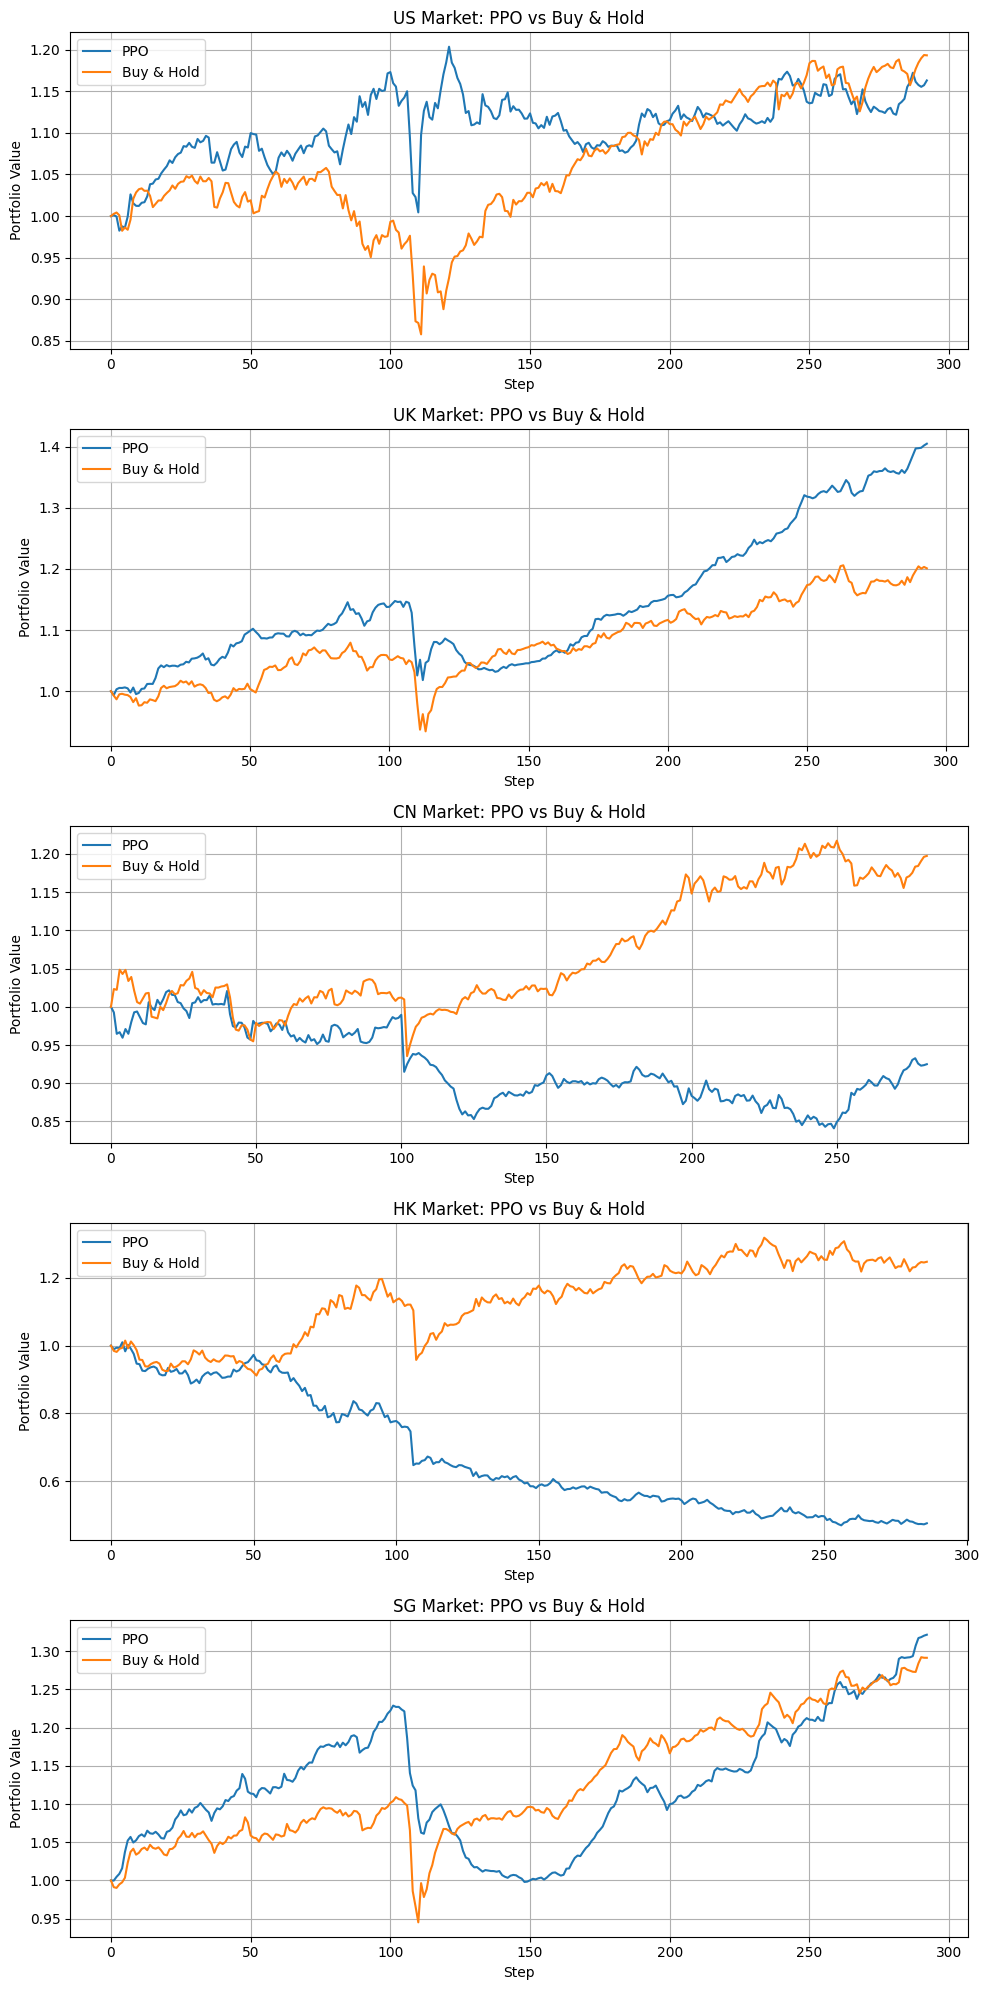

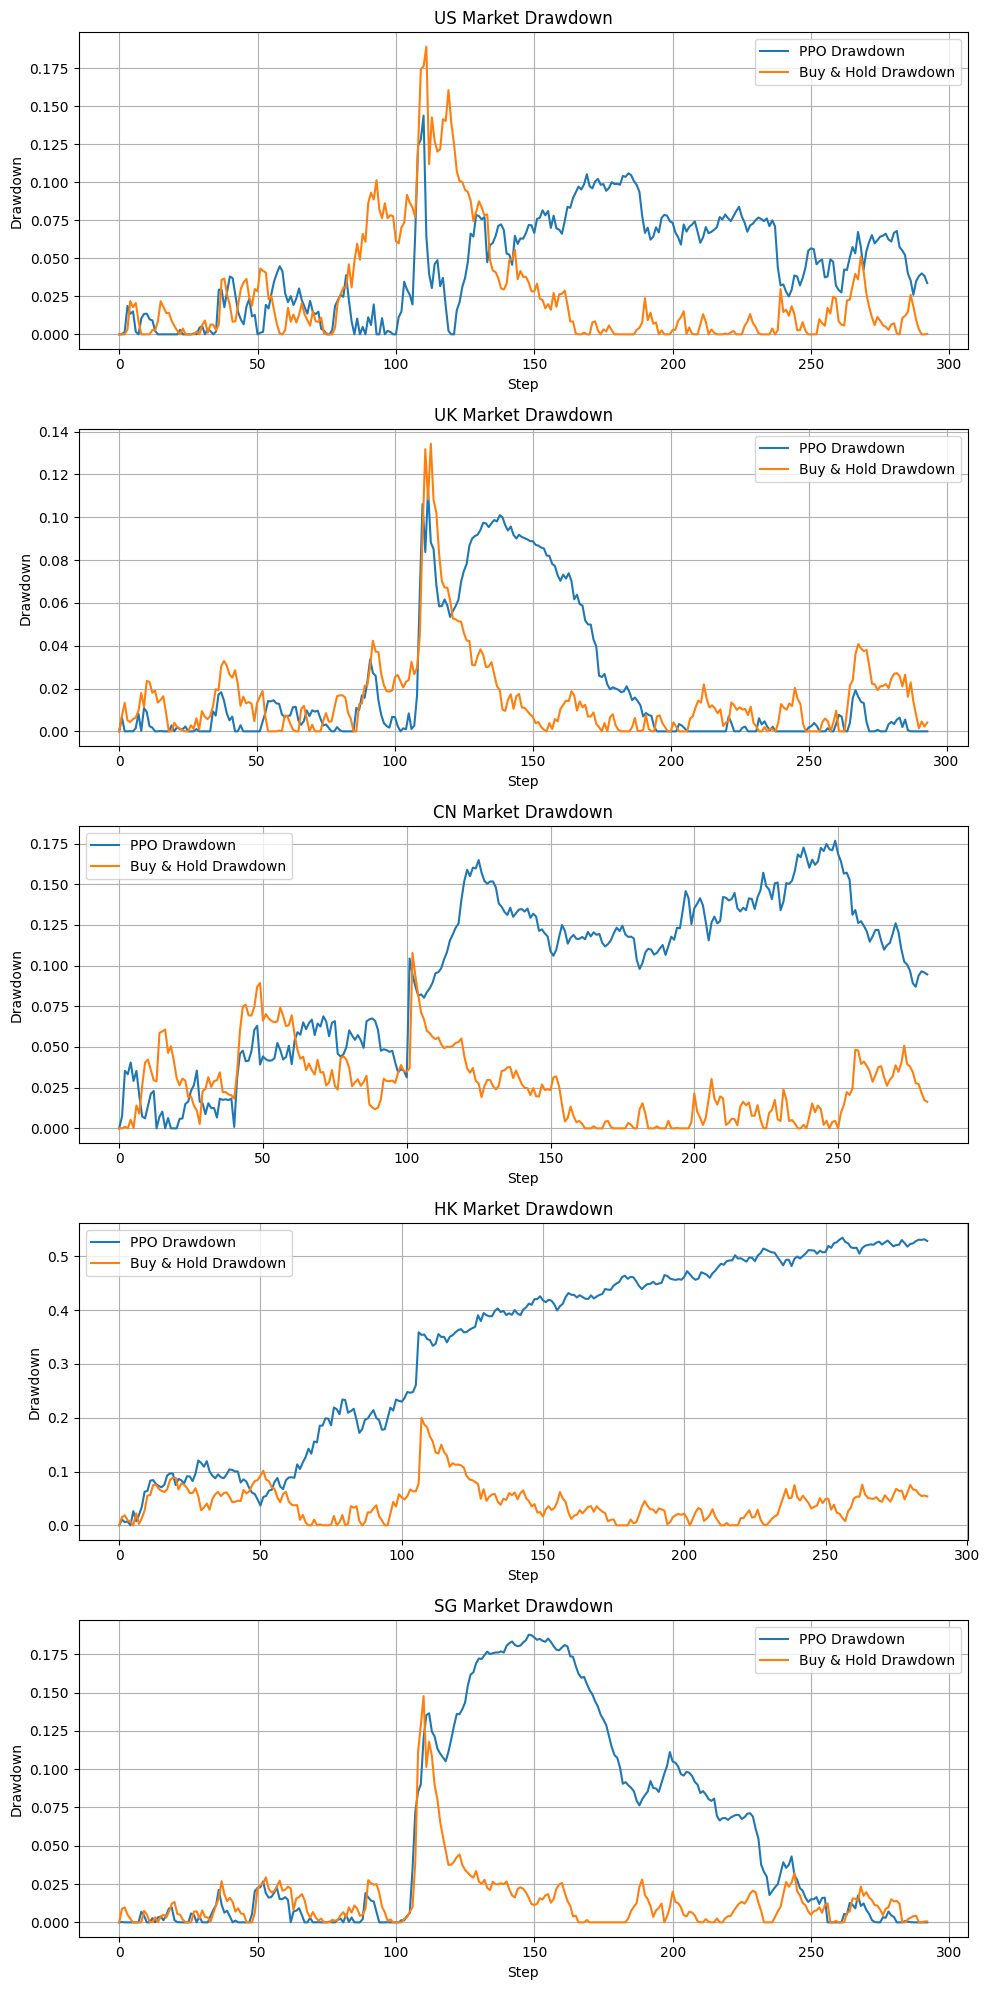

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# Helper: compute drawdown
# ======================================
def compute_drawdown(equity):
    equity = np.array(equity)
    running_max = np.maximum.accumulate(equity)
    drawdown = (running_max - equity) / running_max
    return drawdown


# ======================================
# Equity curves (all markets)
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ax.plot(ppo_curve, label="PPO")
    ax.plot(bh_curve, label="Buy & Hold")

    ax.set_title(f"{market_name} Market: PPO vs Buy & Hold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Portfolio Value")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# ======================================
# Drawdown curves
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ppo_dd = compute_drawdown(ppo_curve)
    bh_dd = compute_drawdown(bh_curve)

    ax.plot(ppo_dd, label="PPO Drawdown")
    ax.plot(bh_dd, label="Buy & Hold Drawdown")

    ax.set_title(f"{market_name} Market Drawdown")
    ax.set_xlabel("Step")
    ax.set_ylabel("Drawdown")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()